# Codigo 6

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import unicodedata 

### A quantidade de horas de sono resulta em possíveis níveis de estresse. Quantas horas de sono são necessárias para o nível de estresse diminuir?

In [17]:
df = pd.read_csv("dataset_sofia.csv")
df.info( )
df["horas_sono"] = pd.to_numeric(df["horas_sono"], errors = "coerce")
df["nivel_estresse"] = pd.to_numeric(df["nivel_estresse"], errors = "coerce")
df = df.dropna(subset = ["horas_sono", "nivel_estresse"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    200 non-null    int64  
 1   horas_sono            199 non-null    float64
 2   tempo_tela            200 non-null    int64  
 3   min_atividade_fisica  200 non-null    int64  
 4   nivel_estresse        199 non-null    float64
 5   copos_agua            200 non-null    int64  
 6   alimentacao           200 non-null    object 
 7   sexo                  200 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 12.6+ KB


# Retirando acentos e cedilhas dos dados


In [18]:
def remover_acentos(texto):
    if isinstance (texto,str):
        normalized = unicodedata.normalize("NFKD", texto)
        return normalized.encode("ascii","ignore").decode("utf-8")
    return texto

In [19]:
for coluna in df.columns:
    df[coluna] = df[coluna].apply(remover_acentos)

# Exemplo 1

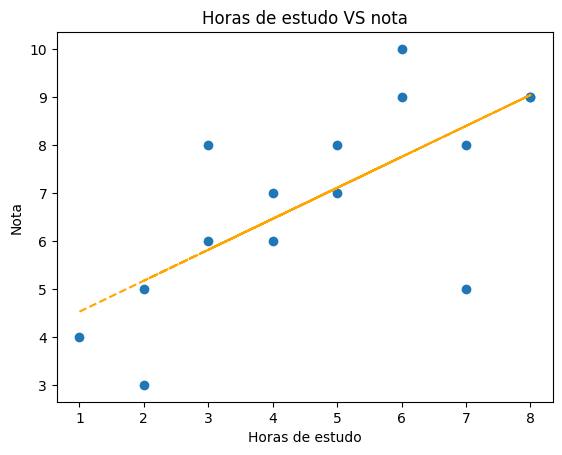

In [20]:
horas_estudo = [1,2,3,4,5,6,2,4,5,7,8,3,6,7,8]
notas = [4,5,6,7,8,10,3,6,7,8,9,8,9,5,9]
plt.scatter(horas_estudo,notas)
coeficientes = np.polyfit(horas_estudo,notas,1)
funcao_tendencia = np.poly1d(coeficientes)
plt.plot (horas_estudo,funcao_tendencia(horas_estudo),color = "orange", linestyle='--')
plt.title("Horas de estudo VS nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.show( )

# Exemplo 2

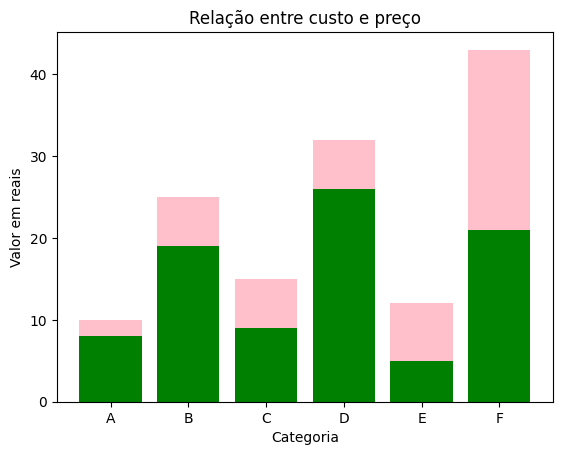

In [21]:
categorias = ["A","B","C","D","E","F"]
precos = [10,25,15,32,12,43]
custos = [8,19,9,26,5,21]
plt.bar(categorias,precos,color="pink")
plt.bar(categorias,custos,color="green")
plt.title("Relação entre custo e preço")
plt.xlabel("Categoria")
plt.ylabel("Valor em reais")
plt.show( )

# Exemplo 3

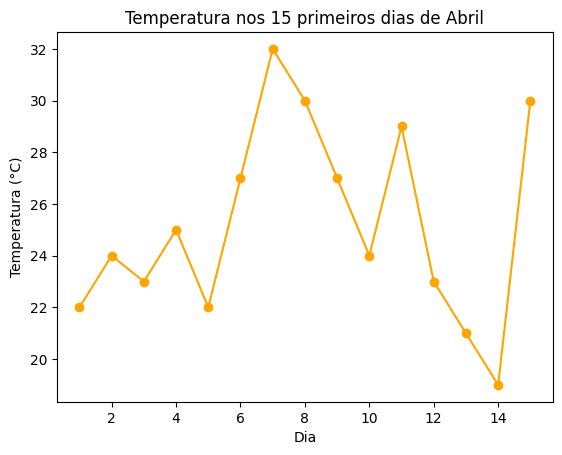

In [22]:
dias = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
temperatura = [22,24,23,25,22,27,32,30,27,24,29,23,21,19,30]
plt.plot(dias,temperatura,marker = "o",color="orange")
plt.title("Temperatura nos 15 primeiros dias de Abril")
plt.xlabel("Dia")
plt.ylabel("Temperatura (°C)")
plt.show( )

### Crie um gráfico com as duas variáveis escolhidas no início:

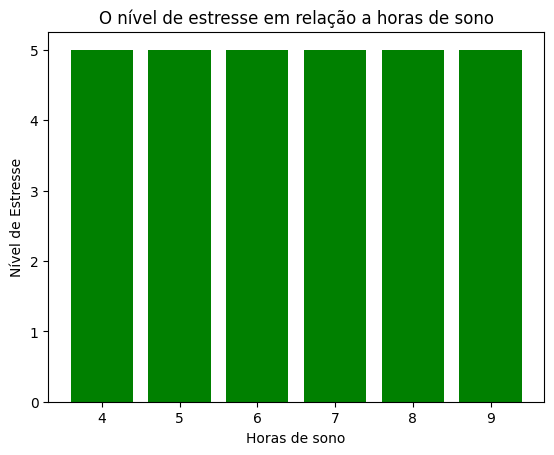

In [32]:
plt.bar(df["horas_sono"],df["nivel_estresse"],color="green")
plt.title("O nível de estresse em relação a horas de sono")
plt.xlabel("Horas de sono")
plt.ylabel("Nível de Estresse")
plt.show( )

### Idependente das horas de sono em que o indivíduo apresenta, o nível de estresse irá ser o mesmo